In [78]:
import numpy as np
import pandas as pd
from pathlib import Path

In [79]:
# Relevant Project Paths:
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
INTERIM_DATA_DIR = DATA_DIR / "interim"

X_test_raw = pd.read_pickle(INTERIM_DATA_DIR / "X_test_raw.pkl")
X_train_clean = pd.read_pickle(INTERIM_DATA_DIR / "X_train_clean.pkl")
y_test_raw = pd.read_pickle(INTERIM_DATA_DIR / "y_test_raw.pkl")
y_train_clean = pd.read_pickle(INTERIM_DATA_DIR / "y_train_clean.pkl")

train_data = pd.concat([X_train_clean.copy(), y_train_clean.copy()], axis=1, join="inner")
train_data.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
31488,41,blue-collar,married,secondary,no,0,yes,no,cellular,1,apr,625,2,no
11946,42,management,single,tertiary,no,-56,yes,no,cellular,20,jun,126,14,no
14355,32,technician,married,tertiary,no,240,yes,yes,cellular,14,jul,86,3,no
39108,24,blue-collar,single,secondary,no,-287,yes,no,cellular,18,may,504,1,no
25294,54,blue-collar,married,secondary,no,1070,no,no,cellular,18,nov,373,4,no


<h3>Feature Selection and Engineering (Encoding + Scaling)

<h4>Categorical Feature Selection

In [80]:
# 1. Using chi-squared values to test if features and the target are independent.

# Null hypothesis (H0): Features and the target are independent.
from scipy.stats import chi2_contingency

cat_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month']
target_column = ['y']
alpha = 0.05

results = []

for col in cat_columns:
    table = pd.crosstab(train_data[col], train_data[target_column[0]])
    chi2, p, dof, expected = chi2_contingency(table)

    h0_rejected = p < alpha

    results.append({
        "feature": col,
        "chi_square": chi2,
        "p_value": p,
        "degrees_of_freedom": dof,
        "H0_rejected": "yes" if h0_rejected else "no"
    })

chi2_results = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
chi2_results


,feature,chi_square,p_value,degrees_of_freedom,H0_rejected
0,month,970.142044,5.045807e-202,10,yes
1,day,269.911107,2.084333e-40,30,yes
2,housing,90.240281,2.109239e-21,1,yes
3,education,84.901683,3.662974e-19,2,yes
4,job,108.714682,9.688725e-19,10,yes
5,marital,81.380259,2.130597e-18,2,yes
6,loan,19.182224,1.188147e-05,1,yes
7,default,0.713972,3.981284e-01,1,no
8,contact,0.076054,7.827176e-01,1,no


In [81]:
# - If HO is rejected (p < 0.05), it means that there is plausibility that there is a dependence of 'y' on the feature column in question. 

# - Only 'default' and 'contact' appears to show independence. (p > 0.05)

In [82]:
# 2. Using Cramers V to find the strength of any association

# Use existing `cat_columns` and target from the notebook
target = target_column[0]  # 'y'

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, c = table.shape
    denom = n * (min(r, c) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

cramers_v_results = pd.DataFrame(
    [{"feature": col, "cramers_v": cramers_v(train_data[col], train_data[target])} for col in cat_columns]
).sort_values("cramers_v", ascending=False).reset_index(drop=True)

cramers_v_results

,feature,cramers_v
0,month,0.190222
1,day,0.100335
2,job,0.063678
3,housing,0.058015
4,education,0.056273
5,marital,0.055094
6,loan,0.026748
7,default,0.005160
8,contact,0.001684


In [83]:
# - Again, 'default' and 'contact' show the weakest association
# - Strangely, 'month' and 'day' appear to show the strongest association with the target.
# - These are cyclical features. What if we try cyclical encoding during feature engineering for these columns?

In [84]:
# 3. Mutual Information:

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# Reuse existing categorical column list from previous cells
X_cat = train_data[cat_columns]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_encoded = encoder.fit_transform(X_cat)

mi_scores = mutual_info_classif(
    X_encoded,
    train_data['y'],
    discrete_features=True,
    random_state=13
)

mi_table = pd.DataFrame({
    "feature": cat_columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

mi_table


,feature,mutual_information
0,month,0.010702
1,day,0.004588
2,job,0.001965
3,housing,0.001657
4,education,0.001545
5,marital,0.001475
6,loan,0.000383
7,default,0.000017
8,contact,0.000002


In [85]:
# - Highest MI scores are for month and day...
# - It seems like exlcuding these would be un-wise.
# - Will make sure to use cyclical encoding rather than ordinal (false distance introduction) or one hot encoding (high dimensionality).

# - 'default' and 'contact' appear to be something that should be removed.

<h4>Numerical Feature Selection

In [86]:
train_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
31488,41,blue-collar,married,secondary,no,0,yes,no,cellular,1,apr,625,2,no
11946,42,management,single,tertiary,no,-56,yes,no,cellular,20,jun,126,14,no
14355,32,technician,married,tertiary,no,240,yes,yes,cellular,14,jul,86,3,no
39108,24,blue-collar,single,secondary,no,-287,yes,no,cellular,18,may,504,1,no
25294,54,blue-collar,married,secondary,no,1070,no,no,cellular,18,nov,373,4,no


In [87]:
numeric_cols = ['age','balance','duration','campaign']

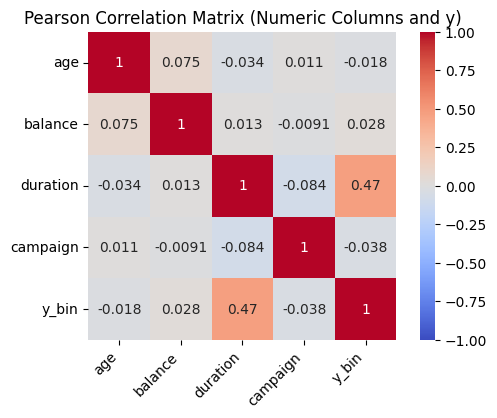

In [88]:
import seaborn as sns

import matplotlib.pyplot as plt

y = train_data['y']

corr_df = train_data[numeric_cols].copy()
corr_df["y_bin"] = (y == "yes").astype(int)

corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Pearson Correlation Matrix (Numeric Columns and y)")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.show()

In [89]:
# - The matrix shows that 'duration' has the highest correlation with y compared to the other numeric columns, 
# and by some margin too...

Based on the analysis so far it seems like the features to remove are:
- Numerical: 'age', 'balance', 'campaign' 
- Categorical: 'default', 'loan', 'contact'

It seems like it would be best to remove these features now before encoding due to the possible introduction of lots of additional features from high cardinality features.

In [90]:
X_train_fs = X_train_clean.drop(columns=['age', 'balance','campaign','default', 'loan', 'contact'])
X_train_fs.head(5)

,job,marital,education,housing,day,month,duration
31488,blue-collar,married,secondary,yes,1,apr,625
11946,management,single,tertiary,yes,20,jun,126
14355,technician,married,tertiary,yes,14,jul,86
39108,blue-collar,single,secondary,yes,18,may,504
25294,blue-collar,married,secondary,no,18,nov,373


In [91]:
# Onto feature engineering

Cyclical and Ordinal/OneHotEncoding:

In [92]:
# Cyclical encoding of day and month:

def cyclical_encode_month_day(df, month_col="month", day_col="day"):
    df = df.copy()

    month_map = {
        "jan": 1,
        "feb": 2,
        "mar": 3,
        "apr": 4,
        "may": 5,
        "jun": 6,
        "jul": 7,
        "aug": 8,
        "sep": 9,
        "oct": 10,
        "nov": 11,
        "dec": 12
    }

    df["month_num"] = df[month_col].str.lower().map(month_map)

    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    df["day_sin"] = np.sin(2 * np.pi * df[day_col] / 31)
    df["day_cos"] = np.cos(2 * np.pi * df[day_col] / 31)

    df = df.drop(columns=[month_col, "month_num", day_col])

    return df

X_train_ce = cyclical_encode_month_day(X_train_fs)
X_train_ce.head(5)

,job,marital,education,housing,duration,month_sin,month_cos,day_sin,day_cos
31488,blue-collar,married,secondary,yes,625,8.660254e-01,-0.500000,0.201299,0.979530
11946,management,single,tertiary,yes,126,1.224647e-16,-1.000000,-0.790776,-0.612106
14355,technician,married,tertiary,yes,86,-5.000000e-01,-0.866025,0.299363,-0.954139
39108,blue-collar,single,secondary,yes,504,5.000000e-01,-0.866025,-0.485302,-0.874347
25294,blue-collar,married,secondary,no,373,-5.000000e-01,0.866025,-0.485302,-0.874347


In [93]:
# Ordinal encoding of housing, and OneHot encoding of the other categorical columns:
X_train_encoded = X_train_ce.copy()

housing_encoder = OrdinalEncoder(
    categories=[["no", "yes"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
X_train_encoded["housing"] = housing_encoder.fit_transform(
    X_train_encoded[["housing"]]
).astype(int)

X_train_encoded = pd.get_dummies(
    X_train_encoded,
    columns=["job", "marital", "education"],
    dtype=int
)

X_train_encoded.head(5)



,housing,duration,month_sin,month_cos,day_sin,day_cos,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,...,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary
31488,1,625,8.660254e-01,-0.500000,0.201299,0.979530,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
11946,1,126,1.224647e-16,-1.000000,-0.790776,-0.612106,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
14355,1,86,-5.000000e-01,-0.866025,0.299363,-0.954139,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
39108,1,504,5.000000e-01,-0.866025,-0.485302,-0.874347,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
25294,0,373,-5.000000e-01,0.866025,-0.485302,-0.874347,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


Scaling:

Will only scale the duration column, not the month and day (sin and cos) columns

In [94]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = X_train_encoded
X_train_scaled["duration"] = scaler.fit_transform(X_train_scaled[["duration"]])
X_train_scaled.head(5)

,housing,duration,month_sin,month_cos,day_sin,day_cos,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,...,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary
31488,1,2.107981,8.660254e-01,-0.500000,0.201299,0.979530,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
11946,1,-0.234742,1.224647e-16,-1.000000,-0.790776,-0.612106,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
14355,1,-0.422535,-5.000000e-01,-0.866025,0.299363,-0.954139,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
39108,1,1.539906,5.000000e-01,-0.866025,-0.485302,-0.874347,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
25294,0,0.924883,-5.000000e-01,0.866025,-0.485302,-0.874347,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


In [95]:
y_train_int = y_train_clean.map({"no": 0, "yes": 1}).astype("int8")
y_train_int.head()

31488    0
11946    0
14355    0
39108    0
25294    0
Name: y, dtype: int8

The X training data is now prepared ready for sampling (due to high class imbalance). Sampling needs to be done before modelling on the training data only.

Function that takes all the preprocessing steps (imputation, FS + FE) into consideration and applies to all splits:

In [96]:
def preprocess_deposit_data(
    X,
    y=None,
    fit=True,
    artifacts=None,
    unknown_value="unknown",
):
    """
    End-to-end preprocessing for the term-deposit notebooks.

    Parameters
    ----------
    X : pd.DataFrame
        Feature dataframe.
    y : pd.Series or pd.DataFrame or None
        Optional target. If provided, encoded as int8 (no->0, yes->1).
    fit : bool
        True: learn imputation/encoders/scaler from input data.
        False: apply previously learned artifacts.
    artifacts : dict or None
        Required when fit=False.
    unknown_value : str
        Placeholder token for missing categorical values in raw data.

    Returns
    -------
    X_out : pd.DataFrame
    y_out : pd.Series or None
    artifacts : dict
    """

    month_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
        "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
    }
    drop_cols = ["age", "balance", "campaign", "default", "loan", "contact"]
    one_hot_cols = ["job", "marital", "education"]

    def first_mode(s):
        m = s.dropna().mode()
        return m.iloc[0] if not m.empty else np.nan

    def prepare_y(y_in):
        if y_in is None:
            return None
        if isinstance(y_in, pd.DataFrame):
            if y_in.shape[1] != 1:
                raise ValueError("y must be a Series or single-column DataFrame")
            y_in = y_in.iloc[:, 0]
        return y_in.copy()

    def encode_target(y_in):
        if y_in is None:
            return None
        y_num = y_in.map({"no": 0, "yes": 1})
        if y_num.isna().any():
            raise ValueError("Target contains values other than yes/no")
        return y_num.astype("int8")

    def cyclical_encode(df):
        out = df.copy()
        if "month" not in out.columns or "day" not in out.columns:
            raise KeyError("Both month and day are required for cyclical encoding")

        month_num = out["month"].astype("string").str.lower().map(month_map)
        day_num = pd.to_numeric(out["day"], errors="coerce")

        if month_num.isna().any():
            raise ValueError("Unexpected month values found")
        if day_num.isna().any():
            raise ValueError("Unexpected day values found")

        out["month_sin"] = np.sin(2 * np.pi * month_num / 12)
        out["month_cos"] = np.cos(2 * np.pi * month_num / 12)
        out["day_sin"] = np.sin(2 * np.pi * day_num / 31)
        out["day_cos"] = np.cos(2 * np.pi * day_num / 31)

        out = out.drop(columns=["month", "day"])
        return out

    y_local = prepare_y(y)
    X_local = X.copy()

    if y_local is not None:
        shared_idx = X_local.index.intersection(y_local.index)
        if len(shared_idx) == 0:
            raise ValueError("X and y have no overlapping index")
        X_local = X_local.loc[shared_idx].copy()
        y_local = y_local.loc[shared_idx].copy()

    needed = ["job", "education", "contact"]
    missing = [c for c in needed if c not in X_local.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    for c in needed:
        X_local[c] = X_local[c].replace(unknown_value, np.nan)

    valid_mask = X_local["job"].notna() & X_local["education"].notna()
    X_local = X_local.loc[valid_mask].copy()
    if y_local is not None:
        y_local = y_local.loc[valid_mask].copy()

    if X_local.empty:
        raise ValueError("No rows left after dropping missing job/education")

    if fit:
        known_contact = X_local.dropna(subset=["contact"]).copy()
        if known_contact.empty:
            raise ValueError("No known contact values to learn imputation rules")

        group_mode = known_contact.groupby(["job", "education"])["contact"].agg(first_mode).to_dict()
        job_mode = known_contact.groupby("job")["contact"].agg(first_mode).to_dict()
        edu_mode = known_contact.groupby("education")["contact"].agg(first_mode).to_dict()
        global_mode = first_mode(known_contact["contact"])
    else:
        if artifacts is None:
            raise ValueError("artifacts must be provided when fit=False")
        group_mode = artifacts["contact_group_mode"]
        job_mode = artifacts["contact_job_mode"]
        edu_mode = artifacts["contact_education_mode"]
        global_mode = artifacts["contact_global_mode"]

    miss_contact_idx = X_local.index[X_local["contact"].isna()]
    for idx in miss_contact_idx:
        j = X_local.at[idx, "job"]
        e = X_local.at[idx, "education"]
        value = group_mode.get((j, e), np.nan)
        if pd.isna(value):
            value = job_mode.get(j, np.nan)
        if pd.isna(value):
            value = edu_mode.get(e, np.nan)
        if pd.isna(value):
            value = global_mode
        X_local.at[idx, "contact"] = value

    X_proc = X_local.drop(columns=[c for c in drop_cols if c in X_local.columns]).copy()
    X_proc = cyclical_encode(X_proc)

    if fit:
        housing_encoder = OrdinalEncoder(
            categories=[["no", "yes"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
        X_proc["housing"] = housing_encoder.fit_transform(X_proc[["housing"]]).astype(int)
        X_proc = pd.get_dummies(X_proc, columns=one_hot_cols, dtype=int)

        scaler = RobustScaler()
        X_proc["duration"] = scaler.fit_transform(X_proc[["duration"]])

        artifacts_out = {
            "contact_group_mode": group_mode,
            "contact_job_mode": job_mode,
            "contact_education_mode": edu_mode,
            "contact_global_mode": global_mode,
            "housing_encoder": housing_encoder,
            "duration_scaler": scaler,
            "feature_columns": X_proc.columns.tolist(),
        }
    else:
        housing_encoder = artifacts["housing_encoder"]
        scaler = artifacts["duration_scaler"]
        feature_columns = artifacts["feature_columns"]

        X_proc["housing"] = housing_encoder.transform(X_proc[["housing"]]).astype(int)
        X_proc = pd.get_dummies(X_proc, columns=one_hot_cols, dtype=int)

        for col in feature_columns:
            if col not in X_proc.columns:
                X_proc[col] = 0
        X_proc = X_proc[feature_columns]
        X_proc["duration"] = scaler.transform(X_proc[["duration"]])

        artifacts_out = artifacts

    y_out = encode_target(y_local)
    return X_proc, y_out, artifacts_out

In [98]:
# Fit on training data
X_train_processed, y_train_processed, prep_artifacts = preprocess_deposit_data(
    X_train_clean,
    y_train_clean,
    fit=True,
)

# Apply to test data with the same learned rules
X_test_processed, y_test_processed, _ = preprocess_deposit_data(
    X_test_raw,
    y_test_raw,
    fit=False,
    artifacts=prep_artifacts,
)

In [99]:
X_train_processed.to_pickle(INTERIM_DATA_DIR / "X_train_processed.pkl")
X_test_processed.to_pickle(INTERIM_DATA_DIR / "X_test_processed.pkl")
y_train_processed.to_pickle(INTERIM_DATA_DIR / "y_train_processed.pkl")
y_test_processed.to_pickle(INTERIM_DATA_DIR / "y_test_processed.pkl")